# SUBSIDE Science Backbone & Time-Burst Notebook

**Author scaffold:** SUBSIDE / TACC · adapted from the *Semantic Bridge* cookbook and the *EPH × Semantic Bridge × Burst* pipeline.

This notebook builds a **science backbone** for the SUBSIDE literature corpus and visualizes how topics, data resources, and scientific **domains** evolve over time.

### What it does, end-to-end

| Step | What happens | Source / inspiration |
|---|---|---|
| 1 | Setup, paths, imports | new |
| 2 | Load a BibTeX file (`Global_SUBSIDE_2024.bib`) and normalize entries | new |
| 3 | **Auto-extract** candidate keywords / topics from `keywords` + `abstract` fields (TF-IDF + LDA) | adapted from `semantic_bridge_cookbook` §3 |
| 4 | **User edits** the keyword groups — pre-seeded with SUBSIDE-relevant domain groups (Subsidence, Groundwater, InSAR/Geodesy, Coastal, Geohazards, Decision Science, …) | adapted from EPH §3.1 (`_GROUP_REGISTRY`) |
| 5 | **Build the science backbone** via three tiers: (1) ETO Map-of-Science CSV export, (2) `semantic_bridge_pipeline.default_science_backbone()`, (3) inlined SUBSIDE-tuned fallback | adapted from EPH §5.1 |
| 6 | Map every keyword group to backbone domains / subdisciplines | adapted from EPH §5.2 |
| 7 | **Interactive backbone network** — domains (blue) ↔ subdisciplines (gray) ↔ keyword groups (colored by primary domain), with hover details, on Plotly | adapted from EPH §5.2 |
| 8 | **Time-burst graphic** — Kleinberg two-state burst detection on **annual** publication frequencies, with three interactive views: (a) keyword/term bursts, (b) **DOMAIN** bursts, (c) key data-resource bursts (InSAR, GNSS, LiDAR, …) | adapted from EPH §6 |
| 9 | Exports — CSV tables and standalone HTML figures | new |

### Required inputs

- A `.bib` file. The TACC default is `/work/01813/sawp33/MySUBSIDE/Global_SUBSIDE_2024.bib`; the cell below also tries a local fallback so the notebook runs anywhere.
- *(Optional)* An ETO Map-of-Science CSV export — leave the path `None` to skip Tier 1 and fall through to the SUBSIDE-tuned inlined backbone.

---

## 1. Setup

Paths, dependency installation, and imports. Run once per kernel session.

### 1.1 Configure paths

`BIB_PATH` should point to the SUBSIDE BibTeX file. The TACC path is tried first; a local file is a fallback. `OUTPUT_DIR` receives every export.


In [1]:
from pathlib import Path
import os

# ── BibTeX source: pick whichever exists in your environment ──────────
CANDIDATE_BIB_PATHS = [
    Path("/work/01813/sawp33/MySUBSIDE/Global_SUBSIDE_2024.bib"),
    Path(os.getcwd()) / "Global_SUBSIDE_2024.bib",
    Path(os.getcwd()) / "data" / "Global_SUBSIDE_2024.bib",
]
BIB_PATH = next((p for p in CANDIDATE_BIB_PATHS if p.exists()),
                CANDIDATE_BIB_PATHS[0])

#OUTPUT_DIR = Path(os.getcwd()) / "ScienceBackboneResults"
OUTPUT_DIR = Path("/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Tier 0: prebuilt backbone JSON from SUBSIDE_ScienceBackbone_Setup.ipynb
# Defaults to the path that setup notebook writes; set to None to skip Tier 0.

import os
SCIENCE_BACKBONE_JSON = Path(os.environ["WORK"]) / "cookbooks" / "SUBSIDE SciMap" / "ScienceBackboneResults" / "science_backbone.json"
# Tier 1: ETO CSV export via sbp (only used if SCIENCE_BACKBONE_JSON is missing)

ETO_EXPORT_PATH = Path(os.environ["WORK"]) / "cookbooks" / "SUBSIDE SciMap" / "eto-map-of-scienceWaterResources.csv"

print(f"BibTeX source : {BIB_PATH}  (exists = {BIB_PATH.exists()})")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Backbone JSON : {SCIENCE_BACKBONE_JSON}  "
      f"(exists = {Path(SCIENCE_BACKBONE_JSON).exists() if SCIENCE_BACKBONE_JSON else False})")
print(f"ETO export    : {ETO_EXPORT_PATH}")


BibTeX source : /work/01813/sawp33/MySUBSIDE/Global_SUBSIDE_2024.bib  (exists = True)
Output dir    : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults
Backbone JSON : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/science_backbone.json  (exists = True)
ETO export    : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/eto-map-of-scienceWaterResources.csv


### 1.2 Install and import dependencies

All packages are mainstream and available on TACC Jupyter kernels. `bibtexparser`, `plotly`, and `networkx` are installed on demand if missing.


In [2]:
import sys, subprocess, importlib

def _ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for _p, _m in [
    ("bibtexparser", "bibtexparser"),
    ("plotly", "plotly"),
    ("networkx", "networkx"),
    ("scikit-learn", "sklearn"),
]:
    _ensure(_p, _m)

import re, json, math
from datetime import datetime, timezone, timedelta
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import bibtexparser
from bibtexparser.bparser import BibTexParser

print("✓ Imports complete")


✓ Imports complete


## 2. Load the BibTeX corpus

Parses the `.bib` file into a tidy DataFrame `df` with one row per entry. Keeps the fields needed downstream: `id`, `year`, `title`, `abstract`, `keywords`, `journal`, `author`, `doi`. Empty `text_content` (the title + abstract + keywords concatenation used by NLP) rows are dropped.

### 2.1 Parse the BibTeX file


In [3]:
def load_bib(path):
    """
    Parse a BibTeX file with bibtexparser, tolerant of common quirks
    ('month' as a string, missing fields, accented characters).
    Returns a list of dicts, one per entry.
    """
    parser = BibTexParser(common_strings=True)
    parser.ignore_nonstandard_types = False
    parser.homogenize_fields = True
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        bib_db = bibtexparser.load(fh, parser=parser)
    return bib_db.entries


def _clean(text):
    """Strip BibTeX braces and collapse whitespace."""
    if not text:
        return ""
    t = re.sub(r"[{}\\]", " ", str(text))
    t = re.sub(r"\s+", " ", t).strip()
    return t


def _year_int(entry):
    y = entry.get("year") or ""
    m = re.search(r"\d{4}", str(y))
    return int(m.group(0)) if m else None


def normalize_entries(entries):
    rows = []
    for e in entries:
        rows.append({
            "id":       e.get("ID") or e.get("id") or "",
            "type":     e.get("ENTRYTYPE") or e.get("type") or "",
            "year":     _year_int(e),
            "title":    _clean(e.get("title")),
            "abstract": _clean(e.get("abstract")),
            "keywords": _clean(e.get("keywords")),
            "journal":  _clean(e.get("journal") or e.get("booktitle")),
            "author":   _clean(e.get("author")),
            "doi":      _clean(e.get("doi")),
        })
    return pd.DataFrame(rows)


if BIB_PATH.exists():
    entries = load_bib(BIB_PATH)
    df = normalize_entries(entries)
else:
    print(f"  ⚠ {BIB_PATH} not found — using empty DataFrame for structure.")
    df = pd.DataFrame(columns=["id","type","year","title","abstract",
                               "keywords","journal","author","doi"])

# Concatenate the NLP-relevant fields into one column for downstream analysis.
df["text_content"] = (df["title"].fillna("") + " . " +
                      df["abstract"].fillna("") + " . " +
                      df["keywords"].fillna(""))
df = df[df["text_content"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"✓ Loaded {len(df):,} entries from {BIB_PATH.name}")


✓ Loaded 8,409 entries from Global_SUBSIDE_2024.bib


### 2.2 Corpus statistics

A quick sanity check before topic modeling. Watch for: a missing-year tail (entries with `year=None` are excluded from the time-burst plots but still used for backbone mapping), an obviously skewed journal distribution, and any entries that lack both `keywords` and `abstract`.


In [4]:
if len(df):
    n_with_year     = df["year"].notna().sum()
    n_with_abstract = (df["abstract"].str.len() > 0).sum()
    n_with_keywords = (df["keywords"].str.len() > 0).sum()
    year_min        = int(df["year"].min()) if n_with_year else None
    year_max        = int(df["year"].max()) if n_with_year else None

    print(f"Entries with year         : {n_with_year:,} / {len(df):,}")
    print(f"Entries with abstract     : {n_with_abstract:,}")
    print(f"Entries with keywords     : {n_with_keywords:,}")
    print(f"Year range                : {year_min} – {year_max}")
    print()
    print("Top 10 journals/venues:")
    print(df["journal"].replace("", np.nan).dropna()
            .value_counts().head(10).to_string())
else:
    print("(no entries loaded)")


Entries with year         : 8,409 / 8,409
Entries with abstract     : 8,409
Entries with keywords     : 0
Year range                : 1977 – 2025

Top 10 journals/venues:
journal
nan                                 660
REMOTE SENSING                      330
ENVIRONMENTAL EARTH SCIENCES        178
JOURNAL OF HYDROLOGY                126
SCIENCE OF THE TOTAL ENVIRONMENT    124
ENGINEERING GEOLOGY                 123
NATURAL HAZARDS                     119
SUSTAINABILITY                      108
WATER                               102
HYDROGEOLOGY JOURNAL                101


## 3. Auto-extract candidate keywords and topics

This is the first half of the *both* strategy: extract candidate vocabulary automatically from the corpus, then in Section 4 surface it for manual editing.

Two passes:

1. **Keyword harvest** — every author-supplied `keywords` field is split on `;`, `,`, and `|`, then ranked by corpus frequency. This is the highest-signal vocabulary because authors chose those terms deliberately.
2. **TF-IDF + LDA over titles + abstracts** — surfaces phrases that *aren't* in author keywords but co-occur across many entries. Both unigrams and bigrams are kept.

### 3.1 Configure stopwords

Standard English stopwords plus subsidence-corpus-specific noise (units, generic verbs, manuscript boilerplate). Edit `CUSTOM_STOPWORDS` to suit your corpus.


In [5]:
STOPWORDS_BASE = {
    # Standard English (compact)
    "a","about","above","after","again","all","am","an","and","any","are","as","at",
    "be","because","been","before","being","below","between","both","but","by","can",
    "did","do","does","doing","don","down","during","each","few","for","from","further",
    "had","has","have","having","he","her","here","hers","herself","him","himself","his",
    "how","i","if","in","into","is","it","its","itself","just","let","me","more","most",
    "my","myself","no","nor","not","now","of","off","on","once","only","or","other",
    "our","ours","ourselves","out","over","own","same","she","should","so","some","such",
    "than","that","the","their","theirs","them","themselves","then","there","these",
    "they","this","those","through","to","too","under","until","up","very","was","we",
    "were","what","when","where","which","while","who","whom","why","will","with","you",
    "your","yours","yourself","yourselves",
    # Article / manuscript boilerplate
    "abstract","study","results","using","used","based","paper","article","analysis",
    "method","methods","approach","approaches","data","also","however","therefore",
    "thus","one","two","three","four","five","first","second","new","high","low",
    "different","various","several","many","much","may","might","could","would","also",
    "et","al","fig","figure","table","section","case","cases","work","propose","proposed",
    "found","shown","show","present","presented","provides","provide","increase","decrease",
    "important","significant","significantly","compared","resulting","obtained",
    # Units, generic numbers
    "mm","cm","km","kg","yr","yrs","year","years","day","days","month","months",
}

CUSTOM_STOPWORDS = set()   # add corpus-specific noise here, e.g. {"foo", "bar"}

ALL_STOPWORDS = STOPWORDS_BASE | CUSTOM_STOPWORDS
print(f"✓ {len(ALL_STOPWORDS):,} stopwords active")


✓ 200 stopwords active


### 3.2 Harvest author-supplied keywords

Splits `keywords` on the common delimiters and ranks by frequency. The top 50 are reported here; the full distribution is available in `keyword_freq`.


In [6]:
def split_keywords(s):
    if not s:
        return []
    raw = re.split(r"[;,|/]", s)
    out = []
    for k in raw:
        k = k.strip().lower()
        if len(k) < 2 or k in ALL_STOPWORDS:
            continue
        # Drop pure numbers, very long phrases
        if k.replace(" ", "").isdigit():
            continue
        if len(k.split()) > 5:
            continue
        out.append(k)
    return out


df["kw_list"] = df["keywords"].apply(split_keywords)
keyword_freq = Counter()
for kws in df["kw_list"]:
    keyword_freq.update(kws)

kw_df = pd.DataFrame(keyword_freq.most_common(),
                     columns=["keyword", "count"])
print(f"✓ {len(kw_df):,} unique author-supplied keywords")
print()
print("Top 50 author-supplied keywords:")
print(kw_df.head(50).to_string(index=False))


✓ 0 unique author-supplied keywords

Top 50 author-supplied keywords:
Empty DataFrame
Columns: [keyword, count]
Index: []


### 3.3 TF-IDF + LDA over titles + abstracts

LDA discovers latent topics over the concatenated `title + abstract` text. The top terms per topic are surface candidates for the keyword-group editor in §4. `N_TOPICS` is tunable.


In [7]:
N_TOPICS         = 10
TOP_TERMS_PER_TOPIC = 12
MAX_VOCAB        = 3000

# Build a corpus suitable for LDA: titles + abstracts (NOT keywords — we want
# to surface phrases the keywords field DIDN'T already capture).
texts = (df["title"].fillna("") + " . " +
         df["abstract"].fillna("")).tolist()

vec = CountVectorizer(
    max_features=MAX_VOCAB,
    stop_words=list(ALL_STOPWORDS),
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.7,
)
X = vec.fit_transform(texts)
vocab = np.array(vec.get_feature_names_out())

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=20,
)
lda.fit(X)

# Top terms per topic
topic_top_terms = []
for k in range(N_TOPICS):
    top_idx = lda.components_[k].argsort()[::-1][:TOP_TERMS_PER_TOPIC]
    topic_top_terms.append(list(vocab[top_idx]))

lda_topics_df = pd.DataFrame({
    "topic_id":  range(N_TOPICS),
    "top_terms": topic_top_terms,
})

# Doc-topic distribution → primary topic per entry
doc_topic = lda.transform(X)
df["primary_lda_topic"] = doc_topic.argmax(axis=1)

print(f"✓ LDA fit on {len(texts):,} docs, {N_TOPICS} topics")
print()
for _, row in lda_topics_df.iterrows():
    print(f"  Topic {row['topic_id']:2d}: {', '.join(row['top_terms'])}")


✓ LDA fit on 8,409 docs, 10 topics

  Topic  0: groundwater, land, land subsidence, aquifer, level, water, model, pumping, groundwater level, area, plain, hydraulic
  Topic  1: basin, sediment, sea, deposits, level, marine, facies, sequence, formation, sea level, depositional, late
  Topic  2: temperature, precipitation, surface, circulation, climate, atmospheric, patients, cloud, impact, rainfall, model, pacific
  Topic  3: deformation, insar, ground, time, land, area, radar, monitoring, surface, series, areas, time series
  Topic  4: basin, fault, uplift, tectonic, faults, seismic, rift, earthquake, along, evolution, similar, margin
  Topic  5: model, models, ground, soil, surface, impact, stress, deformation, numerical, construction, pressure, reservoir
  Topic  6: soil, water, peat, vegetation, permafrost, carbon, organic, surface, textbackslash, ice, lake, changes
  Topic  7: mining, coal, surface, mine, area, coal mining, underground, areas, rock, surface subsidence, china, impac

## 4. User-editable keyword groups

This is the second half of the *both* strategy. Section 3 surfaced candidates; here you compose them into **named keyword groups** that map cleanly to SUBSIDE-relevant scientific domains.

Each group is a list of synonyms / variants — a document matches the group if *any* of its terms appears in `text_content`. The groups are intentionally pre-seeded with SUBSIDE-relevant vocabulary so the notebook produces a meaningful network on first run; **edit them freely** based on what you saw in §3.2 and §3.3.

> **Tip.** Groups are matched as substrings, case-insensitive. `"insar"` matches `"InSAR"` and `"insar-derived"`. Keep groups tight — overly broad groups will sprawl across multiple backbone domains and weaken the network.


In [8]:
# ── Edit this dict to add, remove, or rename keyword groups ───────────
KEYWORD_GROUPS = {
    # Core phenomenon
    "Subsidence":     ["subsidence", "land subsidence", "ground subsidence",
                       "settlement", "compaction", "consolidation"],
    "Uplift_Rebound": ["uplift", "rebound", "heave", "swelling"],

    # Drivers
    "Groundwater":    ["groundwater", "aquifer", "aquifers", "pumping",
                       "withdrawal", "depletion", "drawdown", "phreatic"],
    "OilGas":         ["oil", "gas", "petroleum", "hydrocarbon", "reservoir",
                       "extraction", "production", "co2 storage", "sequestration"],
    "Mining":         ["mining", "mine", "coal mine", "underground mine",
                       "longwall", "subsurface mining"],
    "Tectonic":       ["tectonic", "fault", "faulting", "fault slip", "seismic"],
    "Sediment":       ["sediment", "sedimentation", "deltaic", "delta",
                       "alluvial", "natural compaction"],

    # Observation / measurement methods
    "InSAR":          ["insar", "interferometric", "interferogram", "psinsar",
                       "persistent scatterer", "sentinel-1", "alos", "envisat"],
    "GNSS_GPS":       ["gnss", "gps", "global positioning", "continuous gps",
                       "cgps", "geodetic"],
    "LiDAR":          ["lidar", "light detection and ranging", "airborne lidar",
                       "topobathymetric"],
    "Leveling":       ["leveling", "levelling", "extensometer", "extensometers"],
    "Remote_Sensing": ["remote sensing", "satellite", "earth observation",
                       "sar", "synthetic aperture radar"],

    # Settings / hazards
    "Coastal":        ["coastal", "coast", "shoreline", "tidal", "estuary",
                       "estuaries", "salt marsh", "sea level", "sea-level rise"],
    "Urban":          ["urban", "city", "cities", "metropolitan", "infrastructure"],
    "Flood":          ["flood", "flooding", "inundation", "storm surge"],

    # Modeling / analysis
    "Modeling":       ["model", "modeling", "simulation", "physics-based",
                       "numerical model", "finite element", "finite-element",
                       "modflow"],
    "MachineLearning":["machine learning", "deep learning", "neural network",
                       "random forest", "lstm", "convolutional"],

    # Decision / governance
    "Policy_Decision":["policy", "governance", "stakeholder", "decision support",
                       "management", "regulation", "groundwater management area",
                       "gma"],
}

print(f"✓ {len(KEYWORD_GROUPS)} keyword groups defined")
for k, v in KEYWORD_GROUPS.items():
    print(f"   {k:18s}: {len(v):2d} terms — {', '.join(v[:5])}{'…' if len(v)>5 else ''}")


✓ 18 keyword groups defined
   Subsidence        :  6 terms — subsidence, land subsidence, ground subsidence, settlement, compaction…
   Uplift_Rebound    :  4 terms — uplift, rebound, heave, swelling
   Groundwater       :  8 terms — groundwater, aquifer, aquifers, pumping, withdrawal…
   OilGas            :  9 terms — oil, gas, petroleum, hydrocarbon, reservoir…
   Mining            :  6 terms — mining, mine, coal mine, underground mine, longwall…
   Tectonic          :  5 terms — tectonic, fault, faulting, fault slip, seismic
   Sediment          :  6 terms — sediment, sedimentation, deltaic, delta, alluvial…
   InSAR             :  8 terms — insar, interferometric, interferogram, psinsar, persistent scatterer…
   GNSS_GPS          :  6 terms — gnss, gps, global positioning, continuous gps, cgps…
   LiDAR             :  4 terms — lidar, light detection and ranging, airborne lidar, topobathymetric
   Leveling          :  4 terms — leveling, levelling, extensometer, extensometers
   R

### 4.1 Tag each entry with matching groups

Vectorized substring matching. Every entry ends up with a boolean column `group_<NAME>` and a list column `group_matches`. This is the foundation for the network mapping (§6) and the time-burst views (§8).


In [9]:
def tag_entry(text_lower, groups):
    matches = []
    for name, terms in groups.items():
        if any(t in text_lower for t in terms):
            matches.append(name)
    return matches


text_lc = df["text_content"].str.lower().fillna("")
df["group_matches"] = text_lc.apply(lambda t: tag_entry(t, KEYWORD_GROUPS))

for name in KEYWORD_GROUPS:
    df[f"group_{name}"] = df["group_matches"].apply(lambda lst: name in lst)

# Match-count summary
match_summary = pd.DataFrame([
    {"group": name,
     "matches": int(df[f"group_{name}"].sum()),
     "pct": round(100 * df[f"group_{name}"].mean(), 1)}
    for name in KEYWORD_GROUPS
]).sort_values("matches", ascending=False).reset_index(drop=True)

print("Documents matched per keyword group:")
print(match_summary.to_string(index=False))


Documents matched per keyword group:
          group  matches  pct
     Subsidence     6925 82.4
       Modeling     3621 43.1
         OilGas     2929 34.8
    Groundwater     2914 34.7
          Urban     2893 34.4
         Mining     2692 32.0
       Sediment     2395 28.5
        Coastal     2230 26.5
 Remote_Sensing     2163 25.7
          Flood     2086 24.8
       Tectonic     1808 21.5
Policy_Decision     1565 18.6
          InSAR     1404 16.7
 Uplift_Rebound      964 11.5
       GNSS_GPS      557  6.6
       Leveling      335  4.0
MachineLearning      242  2.9
          LiDAR       94  1.1


## 5. Science backbone — four-tier resolution

The backbone is the domain/subdiscipline scaffolding that the keyword groups get mapped onto. The notebook tries four sources, in order of preference, and uses the **first one that works**:

| Tier | Source | When it's used |
|---|---|---|
| 0 | `science_backbone.json` produced by `SUBSIDE_ScienceBackbone_Setup.ipynb` | Recommended. A referenced, citable backbone combining the UCSD canonical 13-discipline scaffold [Börner et al. 2012] with an ETO Map of Science export if one was provided. |
| 1 | ETO Map-of-Science CSV via `semantic_bridge_pipeline` | You've set `ETO_EXPORT_PATH` and `sbp` is installed |
| 2 | `semantic_bridge_pipeline.default_science_backbone()` | The `sbp` package is installed in the environment (normal TACC kernel) |
| 3 | Inlined SUBSIDE-tuned fallback | Always available — no external dependencies |

Tiers 0 and 3 require no external service. Tier 0 is the preferred path for any publication-bound work; build it once with the setup notebook and commit the JSON alongside the corpus.


In [10]:
SCIENCE_BACKBONE = None
BACKBONE_SOURCE  = None

# ── Tier 0: prebuilt JSON from SUBSIDE_ScienceBackbone_Setup.ipynb ───
# Most-verified, most-portable: a referenced backbone produced once and
# committed alongside the corpus. See SUBSIDE_ScienceBackbone_Setup.ipynb.
if SCIENCE_BACKBONE_JSON and Path(SCIENCE_BACKBONE_JSON).exists():
    try:
        with open(SCIENCE_BACKBONE_JSON) as fh:
            _payload = json.load(fh)
        _selected = _payload.get("selected_layer") or "merged"
        _layers   = _payload.get("layers", {})
        _candidate = _layers.get(_selected) or _layers.get("merged") or _layers.get("ucsd")
        if _candidate:
            # Strip the underscore-prefixed metadata keys for compatibility
            # with the existing mapper in §6; keep originals as inspection-only.
            SCIENCE_BACKBONE = {d: {k: v for k, v in node.items()
                                    if not str(k).startswith("_")}
                                for d, node in _candidate.items()}
            BACKBONE_SOURCE  = (f"Tier 0: prebuilt JSON ({SCIENCE_BACKBONE_JSON.name}, "
                                f"layer='{_selected}', "
                                f"produced {_payload.get('produced_at','?')[:10]})")
    except Exception as e:
        print(f"  ⚠ Tier 0 JSON present but failed to load: {type(e).__name__}: {e}")

# ── Tier 1: ETO Map-of-Science CSV export ────────────────────────────
if SCIENCE_BACKBONE is None and ETO_EXPORT_PATH and Path(ETO_EXPORT_PATH).exists():
    try:
        import semantic_bridge_pipeline as _sbp
        _eto_df = _sbp.load_eto_cluster_export(ETO_EXPORT_PATH)
        _candidate = _sbp.build_science_backbone_from_eto_export(_eto_df)
        if _candidate:
            SCIENCE_BACKBONE = _candidate
            BACKBONE_SOURCE  = f"Tier 1: ETO export via sbp ({ETO_EXPORT_PATH})"
    except Exception as e:
        print(f"  ⚠ ETO export present but failed to load: {type(e).__name__}: {e}")

# ── Tier 2: semantic_bridge_pipeline default ─────────────────────────
if SCIENCE_BACKBONE is None:
    try:
        import semantic_bridge_pipeline as _sbp
        _candidate = _sbp.default_science_backbone()
        if _candidate:
            SCIENCE_BACKBONE = _candidate
            BACKBONE_SOURCE  = "Tier 2: semantic_bridge_pipeline.default_science_backbone()"
    except ImportError:
        pass
    except Exception as e:
        print(f"  ⚠ sbp default backbone failed: {type(e).__name__}: {e}")

# ── Tier 3: SUBSIDE-tuned inlined fallback ───────────────────────────
if SCIENCE_BACKBONE is None:
    SCIENCE_BACKBONE = {
        "Hydrology & Water Resources": {
            "subdisciplines": ["Groundwater Hydrology", "Aquifer Mechanics",
                               "Surface Water", "Water Management"],
            "terms": ["groundwater","aquifer","water","pumping","withdrawal",
                      "drawdown","recharge","modflow","hydrology","watershed"],
        },
        "Geodesy & Remote Sensing": {
            "subdisciplines": ["InSAR", "GNSS Geodesy", "LiDAR",
                               "Satellite Earth Observation"],
            "terms": ["insar","interferometric","sentinel","gps","gnss","lidar",
                      "remote sensing","satellite","sar","geodetic","leveling",
                      "persistent scatterer"],
        },
        "Geomechanics & Geotechnical Engineering": {
            "subdisciplines": ["Soil Mechanics", "Consolidation Theory",
                               "Foundation Engineering"],
            "terms": ["compaction","consolidation","settlement","soil","foundation",
                      "geotechnical","finite element","stress","strain","clay"],
        },
        "Geology & Geophysics": {
            "subdisciplines": ["Sedimentology", "Structural Geology",
                               "Tectonics", "Stratigraphy"],
            "terms": ["sediment","sedimentation","tectonic","fault","seismic",
                      "stratigraphy","delta","alluvial","geological"],
        },
        "Coastal & Marine Science": {
            "subdisciplines": ["Coastal Geomorphology", "Sea-Level Science",
                               "Estuarine Systems"],
            "terms": ["coastal","coast","shoreline","tidal","estuary","sea level",
                      "sea-level","subsidence rate","marsh","delta"],
        },
        "Energy & Resource Extraction": {
            "subdisciplines": ["Petroleum Engineering", "Mining Engineering",
                               "CO2 Storage"],
            "terms": ["oil","gas","petroleum","hydrocarbon","reservoir","mining",
                      "mine","coal","extraction","co2","sequestration","longwall"],
        },
        "Geohazards & Risk": {
            "subdisciplines": ["Hazard Assessment", "Risk Mapping",
                               "Damage & Loss"],
            "terms": ["hazard","risk","damage","vulnerability","susceptibility",
                      "infrastructure damage","subsidence hazard"],
        },
        "Climate & Atmospheric Science": {
            "subdisciplines": ["Climate Change", "Hydroclimate",
                               "Precipitation Variability"],
            "terms": ["climate","climate change","precipitation","drought","warming",
                      "atmospheric","ipcc"],
        },
        "Computational & Data Science": {
            "subdisciplines": ["Machine Learning", "Numerical Modeling",
                               "GIS & Spatial Analytics"],
            "terms": ["machine learning","deep learning","neural network","model",
                      "simulation","numerical","gis","spatial","algorithm"],
        },
        "Public Policy & Decision Science": {
            "subdisciplines": ["Decision Support", "Governance & Regulation",
                               "Stakeholder Engagement"],
            "terms": ["policy","governance","stakeholder","decision support",
                      "management","regulation","gma","groundwater management"],
        },
    }
    BACKBONE_SOURCE = ("Tier 3: SUBSIDE-tuned inlined fallback "
                       "(neither ETO export nor sbp available)")

print(f"✓ {BACKBONE_SOURCE}")
print(f"  {len(SCIENCE_BACKBONE)} domains loaded:")
for d in SCIENCE_BACKBONE:
    print(f"    · {d}")


✓ Tier 0: prebuilt JSON (science_backbone.json, layer='merged', produced 2026-05-11)
  12 domains loaded:
    · Biology
    · Biotechnology
    · Medical Specialties
    · Chemical, Mechanical, & Civil Engineering
    · Chemistry
    · Earth Sciences
    · Electrical Engineering & Computer Science
    · Brain Research
    · Humanities
    · Math & Physics
    · Health Professionals
    · Social Sciences


## 6. Map keyword groups to backbone domains

Every keyword group's term list is scored against every backbone subdiscipline's term list. The top 3 hits (by overlap count) become that group's `backbone_mapping`. A group's **primary domain** is the parent of its highest-scoring subdiscipline.

This is what wires the keyword groups into the network in §7 and the domain-level burst view in §8.


In [11]:
def _node_subs(node):
    if not isinstance(node, dict):
        return ["General"]
    return node.get("subdisciplines") or node.get("subs") or ["General"]

def _node_terms(node):
    if not isinstance(node, dict):
        return []
    return node.get("terms") or node.get("keywords") or []


def map_terms_to_backbone(terms, backbone, top_n=3):
    terms_l = [str(t).lower() for t in terms]
    hits = []
    for domain, node in backbone.items():
        subs = _node_subs(node)
        node_terms = _node_terms(node) or [domain.lower()]
        for sub in subs:
            score = sum(1 for t in terms_l
                        if any(str(kw).lower() in t for kw in node_terms))
            if score > 0:
                hits.append((domain, sub, score))
    if not hits:
        return [("Uncategorized", "General", 0)]
    return sorted(hits, key=lambda x: -x[2])[:top_n]


# Apply to every KEYWORD_GROUPS entry
group_mappings = []
for name, terms in KEYWORD_GROUPS.items():
    mapping = map_terms_to_backbone(terms, SCIENCE_BACKBONE)
    primary_domain = mapping[0][0]
    group_mappings.append({
        "group":            name,
        "primary_domain":   primary_domain,
        "backbone_mapping": mapping,
        "n_matches":        int(df[f"group_{name}"].sum()),
    })

group_mapping_df = pd.DataFrame(group_mappings)
print("Keyword group → primary backbone domain:")
print(group_mapping_df[["group","primary_domain","n_matches"]]
      .to_string(index=False))


Keyword group → primary backbone domain:
          group                            primary_domain  n_matches
     Subsidence                            Earth Sciences       6925
 Uplift_Rebound                             Uncategorized        964
    Groundwater                            Earth Sciences       2914
         OilGas Chemical, Mechanical, & Civil Engineering       2929
         Mining Chemical, Mechanical, & Civil Engineering       2692
       Tectonic                            Earth Sciences       1808
       Sediment                            Earth Sciences       2395
          InSAR                            Earth Sciences       1404
       GNSS_GPS                            Earth Sciences        557
          LiDAR                            Earth Sciences         94
       Leveling                            Earth Sciences        335
 Remote_Sensing                            Earth Sciences       2163
        Coastal                            Earth Sciences     

## 7. Interactive backbone network visualization

Three node tiers, drawn in Plotly:

- **Domains** (large blue circles) — anchored from the backbone.
- **Subdisciplines** (gray circles) — children of each domain.
- **Keyword groups** (diamonds, colored by primary domain) — connected to every subdiscipline they map to, with edge width proportional to the mapping score.

Hover any node to see details. The figure renders inline and is also saved as a standalone HTML file in `OUTPUT_DIR`.


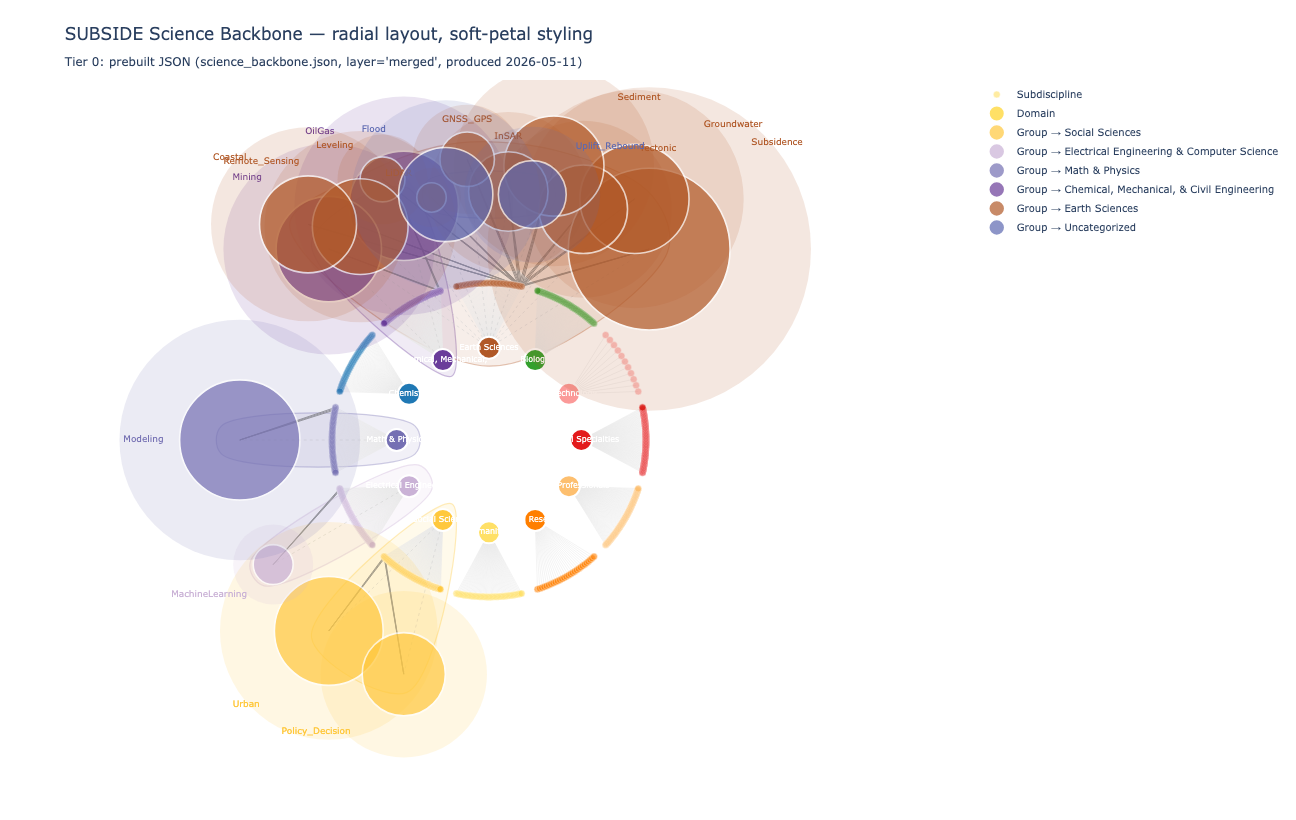

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/science_backbone_network.html


In [14]:
"""
§7 replacement v2 — softer, more elegant treatment.

Same Klavans/Boyack radial layout as v1. Differences:
  - No more diamond markers. Keyword groups are now circles with a soft glow
    (an oversized, low-opacity backing disk behind a crisp foreground disk).
  - Each domain that has keyword groups gets a "petal" polygon: the convex
    hull of (domain_node, *its_keyword_groups), filled in the domain color
    at low opacity. This visually groups them without harsh lines.
  - Subdisciplines are still dot-markers, hover-only labels.
  - Domains keep their published UCSD colors and on-canvas labels.

Drops into the same place in SUBSIDE_Science_Backbone.ipynb §7. Uses the
identical input variables (SCIENCE_BACKBONE, group_mapping_df, OUTPUT_DIR,
BACKBONE_SOURCE) and writes the same HTML output path.
"""

import math
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px

# ── 1. Klavans/Boyack-inspired circular ordering ──────────────────────
KLAVANS_BOYACK_ORDER = [
    "Humanities", "Social Sciences",
    "Electrical Engineering & Computer Science",
    "Math & Physics", "Chemistry",
    "Chemical, Mechanical, & Civil Engineering",
    "Earth Sciences", "Biology", "Biotechnology",
    "Infectious Disease", "Medical Specialties",
    "Health Professionals", "Brain Research",
]
UCSD_HEX = {
    "Math & Physics":                                "#7570B3",
    "Chemistry":                                     "#1F78B4",
    "Earth Sciences":                                "#B15928",
    "Biology":                                       "#33A02C",
    "Biotechnology":                                 "#FB9A99",
    "Infectious Disease":                            "#A6CEE3",
    "Medical Specialties":                           "#E31A1C",
    "Health Professionals":                          "#FDBF6F",
    "Brain Research":                                "#FF7F00",
    "Electrical Engineering & Computer Science":     "#CAB2D6",
    "Chemical, Mechanical, & Civil Engineering":     "#6A3D9A",
    "Social Sciences":                               "#FFC83D",
    "Humanities":                                    "#FFE066",
}

domains_in_backbone = list(SCIENCE_BACKBONE.keys())
ordered_domains = (
    [d for d in KLAVANS_BOYACK_ORDER if d in domains_in_backbone] +
    [d for d in domains_in_backbone if d not in KLAVANS_BOYACK_ORDER]
)

# ── 2. Layout: domains → subdisciplines → keyword groups ──────────────
R_DOMAIN   = 1.0
R_SUB      = 1.7
R_GROUP    = 2.7
ARC_SUBS   = math.radians(24)
ARC_GROUPS = math.radians(20)

pos = {}
domain_angle = {}
for i, d in enumerate(ordered_domains):
    theta = -math.pi/2 - 2 * math.pi * i / max(len(ordered_domains), 1)
    domain_angle[d] = theta
    pos[d] = (R_DOMAIN * math.cos(theta), R_DOMAIN * math.sin(theta))


def _fan(base, n, arc, r):
    if n <= 0: return []
    if n == 1: return [(r * math.cos(base), r * math.sin(base))]
    return [(r * math.cos(base - arc/2 + (j/(n-1)) * arc),
             r * math.sin(base - arc/2 + (j/(n-1)) * arc)) for j in range(n)]


for d in ordered_domains:
    subs = SCIENCE_BACKBONE[d].get("subdisciplines") or ["General"]
    for sub, xy in zip(subs, _fan(domain_angle[d], len(subs), ARC_SUBS, R_SUB)):
        pos[f"{d} :: {sub}"] = xy

group_by_domain = {}
for _, row in group_mapping_df.iterrows():
    group_by_domain.setdefault(row["primary_domain"], []).append(row["group"])
unmatched = [d for d in group_by_domain if d not in domain_angle]
for k, ud in enumerate(unmatched):
    domain_angle[ud] = math.pi/2 + (k - (len(unmatched)-1)/2) * math.radians(10)

for d, groups in group_by_domain.items():
    n = len(groups)
    arc = max(ARC_GROUPS, math.radians(8 * n))
    coords = _fan(domain_angle[d], n, arc, R_GROUP)
    if n > 3:
        for j in range(n):
            stagger = 0.35 if (j % 2 == 1) else 0.0
            x, y = coords[j]; ro = math.hypot(x, y); sc = (ro + stagger) / ro
            coords[j] = (x * sc, y * sc)
    for g, xy in zip(groups, coords):
        pos[g] = xy

# ── 3. Build the graph (for edge drawing) ─────────────────────────────
G = nx.Graph()
for d in ordered_domains:
    G.add_node(d, kind="domain")
    for sub in SCIENCE_BACKBONE[d].get("subdisciplines") or ["General"]:
        sid = f"{d} :: {sub}"
        G.add_node(sid, kind="subdiscipline", label=sub, parent=d)
        G.add_edge(d, sid, edge_kind="scaffold")
for _, row in group_mapping_df.iterrows():
    g = row["group"]
    G.add_node(g, kind="group",
               primary_domain=row["primary_domain"],
               n_matches=int(row["n_matches"]))
    for domain, sub, score in row["backbone_mapping"]:
        sid = f"{domain} :: {sub}"
        if sid in G:
            G.add_edge(g, sid, edge_kind="hit", weight=float(score))
    if row["primary_domain"] in G:
        G.add_edge(g, row["primary_domain"], edge_kind="anchor")

# ── 4. Color resolver + helpers ───────────────────────────────────────
QUAL = px.colors.qualitative.Bold + px.colors.qualitative.Vivid
def domain_color(d):
    if d in UCSD_HEX:
        return UCSD_HEX[d]
    idx = (ordered_domains + unmatched).index(d) if d in ordered_domains or d in unmatched else 0
    return QUAL[idx % len(QUAL)]
DOMAIN_COLORS = {d: domain_color(d) for d in ordered_domains + unmatched}
DOMAIN_COLORS.setdefault("Uncategorized", "#9a9a9a")


def _hex_to_rgba(color, alpha):
    """Convert any of '#RRGGBB', '#RGB', 'rgb(r,g,b)', or 'rgba(r,g,b,a)' to rgba string."""
    s = str(color).strip()
    if s.startswith("rgb"):
        # 'rgb(r,g,b)' or 'rgba(r,g,b,a)' — replace alpha and return
        inner = s[s.index("(")+1:s.rindex(")")]
        parts = [p.strip() for p in inner.split(",")]
        r, g, b = int(float(parts[0])), int(float(parts[1])), int(float(parts[2]))
        return f"rgba({r},{g},{b},{alpha})"
    h = s.lstrip("#")
    if len(h) == 3:
        h = "".join(c * 2 for c in h)
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def _convex_hull(points):
    """Andrew's monotone chain. Returns hull in CCW order (or short list for ≤2 pts)."""
    pts = sorted(set(points))
    if len(pts) < 2:
        return pts
    def cross(o, a, b):
        return (a[0]-o[0]) * (b[1]-o[1]) - (a[1]-o[1]) * (b[0]-o[0])
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    return lower[:-1] + upper[:-1]


def _inflate_hull(hull_pts, margin=0.18):
    """Push each hull vertex slightly outward from the centroid. Smooths the shape."""
    if len(hull_pts) < 2:
        return hull_pts
    cx = sum(p[0] for p in hull_pts) / len(hull_pts)
    cy = sum(p[1] for p in hull_pts) / len(hull_pts)
    inflated = []
    for x, y in hull_pts:
        dx, dy = x - cx, y - cy
        dist = math.hypot(dx, dy) or 1.0
        inflated.append((x + dx/dist * margin, y + dy/dist * margin))
    return inflated


# ── 5. Draw ───────────────────────────────────────────────────────────
traces = []

# (a) Domain "petal" polygons — convex hull of (domain_node, *its_groups)
for d in ordered_domains + unmatched:
    groups = group_by_domain.get(d, [])
    if not groups:
        continue
    if d in pos:
        pts = [pos[d]] + [pos[g] for g in groups if g in pos]
    else:
        pts = [pos[g] for g in groups if g in pos]
    if len(pts) < 2:
        continue
    hull = _convex_hull(pts)
    hull = _inflate_hull(hull, margin=0.20)
    if len(hull) < 3:
        # 2 points: draw a thin lozenge by perpendicular offset
        (x1, y1), (x2, y2) = hull
        dx, dy = x2 - x1, y2 - y1
        ll = math.hypot(dx, dy) or 1.0
        nx_, ny_ = -dy/ll * 0.15, dx/ll * 0.15
        hull = [(x1+nx_, y1+ny_), (x2+nx_, y2+ny_), (x2-nx_, y2-ny_), (x1-nx_, y1-ny_)]
    xs = [p[0] for p in hull] + [hull[0][0]]
    ys = [p[1] for p in hull] + [hull[0][1]]
    color = DOMAIN_COLORS.get(d, "#888")
    traces.append(go.Scatter(
        x=xs, y=ys, mode="lines",
        line=dict(color=_hex_to_rgba(color, 0.35), width=1.2, shape="spline"),
        fill="toself", fillcolor=_hex_to_rgba(color, 0.10),
        hoverinfo="skip", showlegend=False))

# (b) Edges, split by kind
backbone_x, backbone_y = [], []
anchor_x, anchor_y     = [], []
hit_x, hit_y           = [], []
for u, v, ed in G.edges(data=True):
    ux, uy = pos.get(u, (0, 0)); vx, vy = pos.get(v, (0, 0))
    kind = ed.get("edge_kind")
    if kind == "hit":
        hit_x += [ux, vx, None]; hit_y += [uy, vy, None]
    elif kind == "anchor":
        anchor_x += [ux, vx, None]; anchor_y += [uy, vy, None]
    else:
        backbone_x += [ux, vx, None]; backbone_y += [uy, vy, None]

traces.append(go.Scatter(x=backbone_x, y=backbone_y, mode="lines",
                         line=dict(color="#e8e8e8", width=0.5),
                         hoverinfo="none", showlegend=False))
traces.append(go.Scatter(x=anchor_x, y=anchor_y, mode="lines",
                         line=dict(color="#cccccc", width=0.5, dash="dot"),
                         hoverinfo="none", showlegend=False))
traces.append(go.Scatter(x=hit_x, y=hit_y, mode="lines",
                         line=dict(color="#9a9a9a", width=1.0),
                         hoverinfo="none", showlegend=False))

# (c) Subdisciplines — small dots, hover-only labels
sub_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "subdiscipline"]
sub_colors = [DOMAIN_COLORS.get(G.nodes[n]["parent"], "#b0b0b0") for n in sub_nodes]
traces.append(go.Scatter(
    x=[pos[n][0] for n in sub_nodes], y=[pos[n][1] for n in sub_nodes],
    mode="markers",
    marker=dict(size=7, color=sub_colors, opacity=0.6,
                line=dict(color="white", width=0.5)),
    hovertext=[f"<b>{G.nodes[n]['label']}</b><br>parent: {G.nodes[n]['parent']}"
               for n in sub_nodes],
    hoverinfo="text",
    name="Subdiscipline"))

# (d) Domains — colored disks with white labels
dom_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "domain"]
traces.append(go.Scatter(
    x=[pos[n][0] for n in dom_nodes], y=[pos[n][1] for n in dom_nodes],
    mode="markers+text",
    marker=dict(size=22, color=[DOMAIN_COLORS.get(n, "#888") for n in dom_nodes],
                line=dict(color="white", width=2)),
    text=[n.split(" & ")[0] if len(n) > 22 else n for n in dom_nodes],
    textposition="middle center", textfont=dict(size=8, color="white"),
    hovertext=[f"<b>{n}</b><br>(domain)<br>"
               f"{len(SCIENCE_BACKBONE[n].get('subdisciplines', []))} subdisciplines"
               for n in dom_nodes],
    hoverinfo="text",
    name="Domain"))

# (e) Keyword groups — soft glow + crisp circle, one trace pair per domain
for d in ordered_domains + unmatched:
    grp_nodes = [n for n, dd in G.nodes(data=True)
                 if dd.get("kind") == "group" and dd.get("primary_domain") == d]
    if not grp_nodes:
        continue
    color = DOMAIN_COLORS.get(d, "#888")
    sizes = [12 + math.sqrt(max(G.nodes[n].get("n_matches", 0), 1)) * 1.8
             for n in grp_nodes]
    # Glow layer (drawn first, larger, faded)
    traces.append(go.Scatter(
        x=[pos[n][0] for n in grp_nodes], y=[pos[n][1] for n in grp_nodes],
        mode="markers",
        marker=dict(size=[s * 2.0 for s in sizes],
                    color=_hex_to_rgba(color, 0.20),
                    line=dict(width=0)),
        hoverinfo="skip", showlegend=False))
    # Foreground circle + label
    def _lp(x, y):
        if   x >=  0.3 and y >=  0.3: return "top right"
        elif x <= -0.3 and y >=  0.3: return "top left"
        elif x <= -0.3 and y <= -0.3: return "bottom left"
        elif x >=  0.3 and y <= -0.3: return "bottom right"
        elif x >=  0.3:               return "middle right"
        elif x <= -0.3:               return "middle left"
        elif y >=  0.3:               return "top center"
        else:                          return "bottom center"
    positions = [_lp(pos[n][0], pos[n][1]) for n in grp_nodes]
    traces.append(go.Scatter(
        x=[pos[n][0] for n in grp_nodes], y=[pos[n][1] for n in grp_nodes],
        mode="markers+text",
        marker=dict(size=sizes, color=color, symbol="circle",
                    line=dict(color="white", width=1.6)),
        text=grp_nodes, textposition=positions,
        textfont=dict(size=9, color=color),
        hovertext=[f"<b>{n}</b><br>primary domain: {d}"
                   f"<br>matched docs: {G.nodes[n].get('n_matches', 0)}"
                   for n in grp_nodes],
        hoverinfo="text",
        name=f"Group → {d}"))

fig_network = go.Figure(traces, layout=go.Layout(
    title=("SUBSIDE Science Backbone — radial layout, soft-petal styling"
           f"<br><sub>{BACKBONE_SOURCE}</sub>"),
    showlegend=True, hovermode="closest", height=820,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               range=[-3.9, 3.9]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               scaleanchor="x", scaleratio=1, range=[-3.9, 3.9]),
    plot_bgcolor="white",
    legend=dict(orientation="v", yanchor="top", y=1.0,
                xanchor="left", x=1.02, font=dict(size=10)),
    margin=dict(l=20, r=20, t=80, b=20),
))
fig_network.write_html(str(OUTPUT_DIR / "science_backbone_network.html"),
                       include_plotlyjs="cdn")
fig_network.show()
print(f"✓ Saved: {OUTPUT_DIR / 'science_backbone_network.html'}")


## 8. Time-burst graphic — annual bursts for terms, **DOMAINS**, and data resources

Kleinberg's two-state burst model identifies time windows where a term's frequency is anomalously high relative to its baseline rate. Here it's applied to **annual publication frequencies** computed from the BibTeX `year` field.

Three views, all interactive Plotly heatmaps:

- **8.2 — Term-level bursts.** The most distinctive terms (by TF-IDF) across the corpus, plotted year × term, color = burst intensity.
- **8.3 — Domain-level bursts.** Annual counts of papers whose `text_content` matches at least one term in each backbone domain, run through the same burst detector. Lets you see at a glance when *Geodesy & Remote Sensing* surged (likely with InSAR availability), when *Coastal & Marine Science* started bursting (likely as sea-level concerns ramped), etc.
- **8.4 — Data-resource bursts.** Same view, but for named data resources (InSAR, GNSS, LiDAR, SAR, leveling, extensometers, MODFLOW, …).

### 8.1 Annual Kleinberg burst detector


In [15]:
def kleinberg_bursts_annual(year_counts, s=2.0, gamma=1.0):
    """
    Annual-binned Kleinberg two-state burst detector.

    Parameters
    ----------
    year_counts : dict[int, int]
        Year → number of occurrences in that year.
    s : float
        Burst-state rate multiplier (higher = fewer, larger bursts).
    gamma : float
        State-change penalty.

    Returns
    -------
    list[tuple[int, int, float]]
        (start_year, end_year, intensity) per detected burst window.

    Adapted from the Kleinberg detector in the EPH × Semantic Bridge × Burst
    notebook. Here counts are converted to a sequence of "events" with
    sub-year jitter so the same Viterbi machinery applies; this preserves the
    original algorithm while letting us run it on annual bins.
    """
    if not year_counts:
        return []

    years_sorted = sorted(year_counts)
    timestamps = []
    rng = np.random.default_rng(42)
    for y in years_sorted:
        n = int(year_counts[y])
        if n <= 0:
            continue
        # Evenly spread the n events through the year (deterministic, reproducible)
        offsets = (np.arange(n) + 0.5) / n
        timestamps.extend([y + float(o) for o in offsets])

    if len(timestamps) < 4:
        return []

    times = sorted(timestamps)
    gaps  = [max(times[i+1] - times[i], 1e-6) for i in range(len(times)-1)]
    mean_gap = float(np.mean(gaps))
    if mean_gap <= 0:
        return []

    rates = [1.0 / mean_gap, s / mean_gap]
    n = len(gaps)
    cost = [[0.0, 0.0] for _ in range(n)]
    back = [[0, 0] for _ in range(n)]
    for k in (0, 1):
        cost[0][k] = -np.log(rates[k] * np.exp(-rates[k] * gaps[0]))
    for i in range(1, n):
        for k in (0, 1):
            best, best_prev = None, 0
            for j in (0, 1):
                trans = (k - j) * gamma * np.log(n) if k > j else 0.0
                c = cost[i-1][j] + trans - np.log(rates[k] * np.exp(-rates[k]*gaps[i]))
                if best is None or c < best:
                    best, best_prev = c, j
            cost[i][k] = best
            back[i][k] = best_prev

    path = [0] * n
    path[-1] = 0 if cost[-1][0] <= cost[-1][1] else 1
    for i in range(n-2, -1, -1):
        path[i] = back[i+1][path[i+1]]

    bursts = []
    in_burst, start_idx = False, 0
    for i, st in enumerate(path):
        if st == 1 and not in_burst:
            in_burst, start_idx = True, i
        elif st == 0 and in_burst:
            intensity = sum(1/gaps[j] for j in range(start_idx, i)) / max(i-start_idx, 1)
            bursts.append((int(times[start_idx]), int(times[i]), float(intensity)))
            in_burst = False
    if in_burst:
        intensity = sum(1/gaps[j] for j in range(start_idx, n)) / max(n-start_idx, 1)
        bursts.append((int(times[start_idx]), int(times[-1]), float(intensity)))

    return bursts


print("✓ Annual Kleinberg burst detector defined")


✓ Annual Kleinberg burst detector defined


### 8.2 Term-level burst heatmap

Pick the N most distinctive terms in the corpus (by TF-IDF over `text_content`, weighted by year coverage), compute per-year occurrence counts for each, and run the burst detector. The heatmap encodes burst intensity; cells outside any burst window are zero.


  Window: 1977–2025 (49 years)
  Top 20 distinctive terms identified


/tmp/ipykernel_3873435/1550925816.py:52: RuntimeWarning:

divide by zero encountered in log



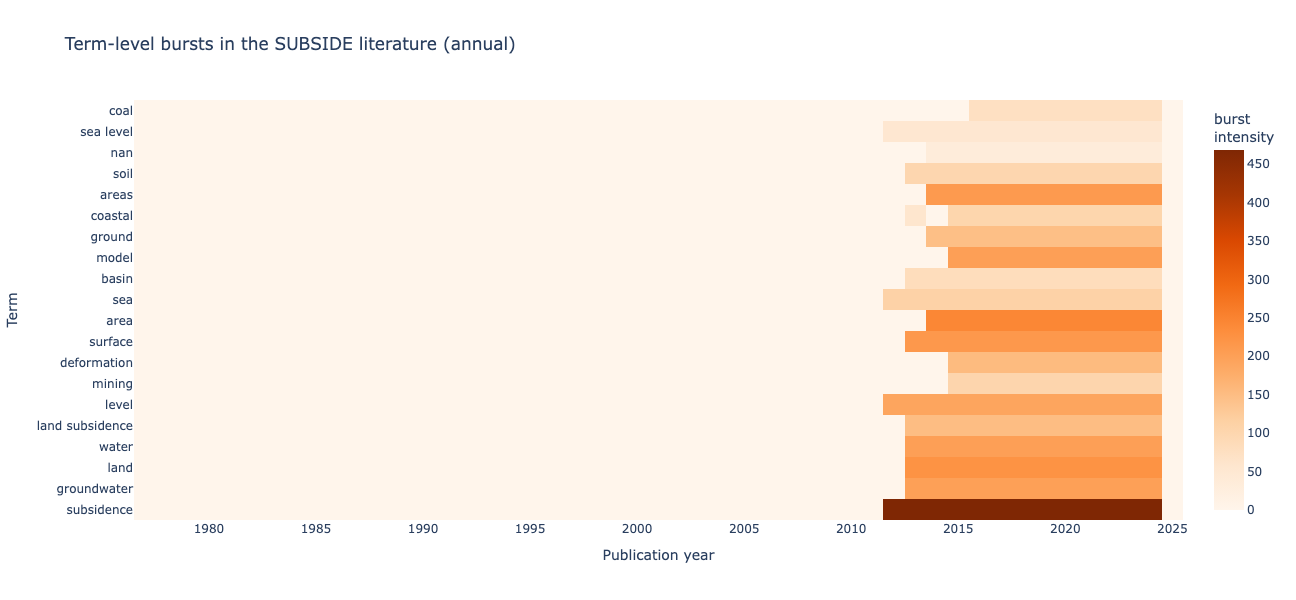

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/burst_terms.html


In [16]:
N_BURST_TERMS = 20

def doc_year_series(df_local):
    """Return only rows that have a parseable year, with year as int."""
    sub = df_local[df_local["year"].notna()].copy()
    sub["year"] = sub["year"].astype(int)
    return sub


def term_year_counts(docs, term):
    """Count of docs (per year) whose text_content contains `term` as a word."""
    pat = re.compile(rf"\b{re.escape(term.lower())}\b")
    mask = docs["text_content"].str.lower().apply(lambda t: bool(pat.search(t)))
    return docs.loc[mask].groupby("year").size().to_dict()


def top_corpus_terms(docs, stopwords, n=N_BURST_TERMS):
    vec = TfidfVectorizer(
        max_features=3000, stop_words=list(stopwords),
        ngram_range=(1, 2), min_df=5,
    )
    X = vec.fit_transform(docs["text_content"].tolist())
    means = np.asarray(X.mean(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    # Filter out terms that are basically year strings or single chars
    keep = [(t, m) for t, m in zip(vocab, means) if not t.isdigit() and len(t) > 2]
    keep.sort(key=lambda x: -x[1])
    return [t for t, _ in keep[:n]]


docs_year = doc_year_series(df)
if len(docs_year):
    year_min = int(docs_year["year"].min())
    year_max = int(docs_year["year"].max())
    years_axis = list(range(year_min, year_max + 1))

    burst_terms = top_corpus_terms(docs_year, ALL_STOPWORDS, n=N_BURST_TERMS)
    print(f"  Window: {year_min}–{year_max} ({len(years_axis)} years)")
    print(f"  Top {len(burst_terms)} distinctive terms identified")

    matrix = np.zeros((len(burst_terms), len(years_axis)))
    for ti, term in enumerate(burst_terms):
        yc = term_year_counts(docs_year, term)
        bursts = kleinberg_bursts_annual(yc)
        for b_start, b_end, intensity in bursts:
            for y in range(b_start, b_end + 1):
                if year_min <= y <= year_max:
                    j = y - year_min
                    matrix[ti, j] = max(matrix[ti, j], intensity)

    fig_term_burst = go.Figure(go.Heatmap(
        z=matrix, x=years_axis, y=burst_terms,
        colorscale="Oranges",
        colorbar=dict(title="burst<br>intensity"),
        hovertemplate="Year %{x}<br>Term: %{y}<br>Intensity: %{z:.2f}<extra></extra>",
    ))
    fig_term_burst.update_layout(
        title="Term-level bursts in the SUBSIDE literature (annual)",
        xaxis_title="Publication year",
        yaxis_title="Term",
        height=600, plot_bgcolor="white",
    )
    fig_term_burst.write_html(str(OUTPUT_DIR / "burst_terms.html"),
                              include_plotlyjs="cdn")
    fig_term_burst.show()
    print(f"✓ Saved: {OUTPUT_DIR / 'burst_terms.html'}")
else:
    print("(no entries with valid year — skipping term burst heatmap)")


### 8.3 **Domain-level** burst heatmap

For each backbone domain, count the number of documents per year whose `text_content` matches *any* of that domain's terms (from §5). Run the burst detector on those annual counts. This produces the *DOMAINS through time* view the user asked for.

This is the most informative view for a 30-second skim of the corpus: it shows the rise of *Geodesy & Remote Sensing* alongside InSAR maturation, the recent surge in *Computational & Data Science*, and so on.


/tmp/ipykernel_3873435/1550925816.py:58: RuntimeWarning:

divide by zero encountered in log

/tmp/ipykernel_3873435/1550925816.py:58: RuntimeWarning:

divide by zero encountered in log

/tmp/ipykernel_3873435/1550925816.py:58: RuntimeWarning:

divide by zero encountered in log

/tmp/ipykernel_3873435/1550925816.py:58: RuntimeWarning:

divide by zero encountered in log

/tmp/ipykernel_3873435/1550925816.py:58: RuntimeWarning:

divide by zero encountered in log



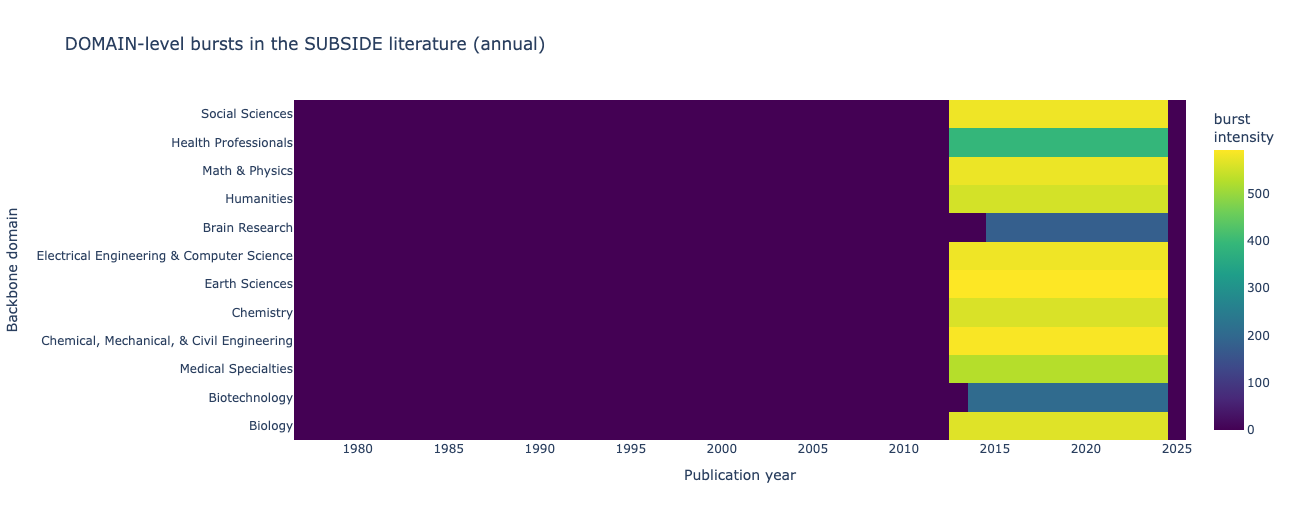

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/burst_domains.html


In [17]:
def domain_year_counts(docs, domain_terms):
    """Annual count of docs matching ANY term in domain_terms."""
    if not domain_terms:
        return {}
    pat = re.compile(r"\b(" + "|".join(re.escape(t.lower()) for t in domain_terms) + r")\b")
    mask = docs["text_content"].str.lower().apply(lambda t: bool(pat.search(t)))
    return docs.loc[mask].groupby("year").size().to_dict()


if len(docs_year):
    domain_names = list(SCIENCE_BACKBONE.keys())
    matrix_d = np.zeros((len(domain_names), len(years_axis)))
    raw_counts_d = np.zeros_like(matrix_d)

    for di, domain in enumerate(domain_names):
        terms = _node_terms(SCIENCE_BACKBONE[domain])
        yc = domain_year_counts(docs_year, terms)
        # Record raw counts for the hover (so users see what fed the burst calc)
        for y, c in yc.items():
            if year_min <= y <= year_max:
                raw_counts_d[di, y - year_min] = c
        # Burst calc
        bursts = kleinberg_bursts_annual(yc)
        for b_start, b_end, intensity in bursts:
            for y in range(b_start, b_end + 1):
                if year_min <= y <= year_max:
                    j = y - year_min
                    matrix_d[di, j] = max(matrix_d[di, j], intensity)

    custom = np.stack([raw_counts_d], axis=-1)

    fig_domain_burst = go.Figure(go.Heatmap(
        z=matrix_d, x=years_axis, y=domain_names,
        colorscale="Viridis",
        colorbar=dict(title="burst<br>intensity"),
        customdata=custom,
        hovertemplate=("Year %{x}<br>Domain: %{y}"
                       "<br>Burst intensity: %{z:.2f}"
                       "<br>Papers in year: %{customdata[0]:.0f}"
                       "<extra></extra>"),
    ))
    fig_domain_burst.update_layout(
        title="DOMAIN-level bursts in the SUBSIDE literature (annual)",
        xaxis_title="Publication year",
        yaxis_title="Backbone domain",
        height=520, plot_bgcolor="white",
        margin=dict(l=240),    # room for long domain labels
    )
    fig_domain_burst.write_html(str(OUTPUT_DIR / "burst_domains.html"),
                                include_plotlyjs="cdn")
    fig_domain_burst.show()
    print(f"✓ Saved: {OUTPUT_DIR / 'burst_domains.html'}")
else:
    print("(no entries with valid year — skipping domain burst heatmap)")


### 8.4 Key data-resource burst heatmap

A curated list of named **data resources** relevant to subsidence work. Edit `DATA_RESOURCES` to add (e.g.) sensor families, model codes, or named datasets specific to your study. Each resource is matched as a regex word boundary so `"GNSS"` doesn't accidentally hit `"gnssr"`.


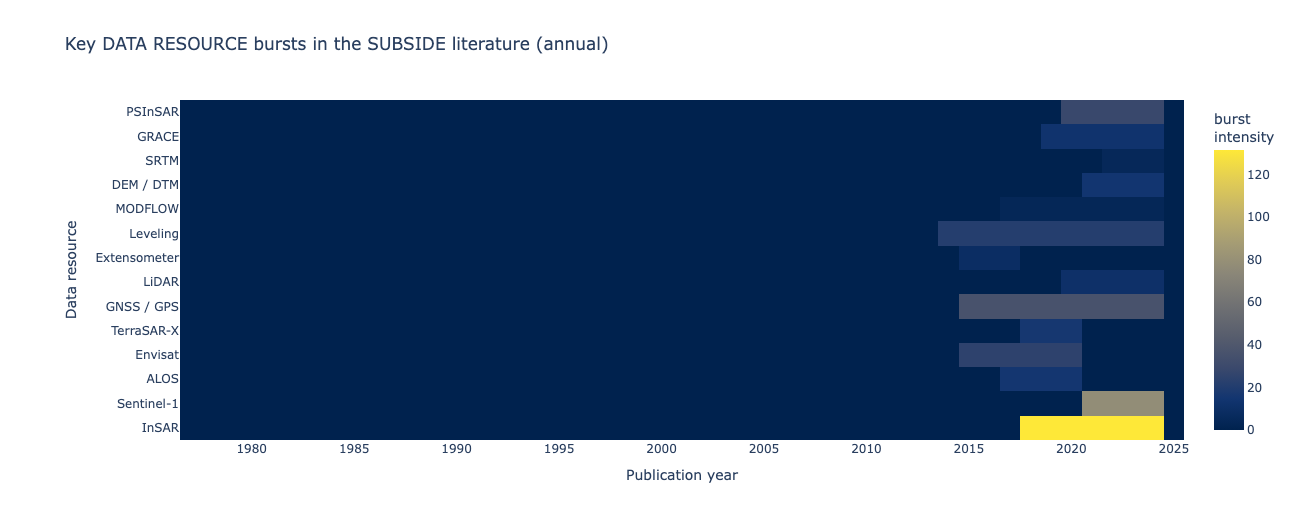

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/burst_resources.html


In [18]:
DATA_RESOURCES = {
    # Geodetic / remote sensing instruments
    "InSAR":            ["insar", "interferometric synthetic aperture radar"],
    "Sentinel-1":       ["sentinel-1", "sentinel 1"],
    "ALOS":             ["alos", "palsar"],
    "Envisat":          ["envisat"],
    "TerraSAR-X":       ["terrasar", "terrasar-x"],
    "GNSS / GPS":       ["gnss", "gps"],
    "LiDAR":            ["lidar"],
    "Extensometer":     ["extensometer", "extensometers"],
    "Leveling":         ["leveling", "levelling"],
    # Model codes & data products
    "MODFLOW":          ["modflow"],
    "DEM / DTM":        ["digital elevation model", "dem", "dtm"],
    "SRTM":             ["srtm"],
    # Aggregating data sources
    "GRACE":            ["grace"],
    "PSInSAR":          ["psinsar", "persistent scatterer"],
}

if len(docs_year):
    res_names = list(DATA_RESOURCES.keys())
    matrix_r = np.zeros((len(res_names), len(years_axis)))
    raw_counts_r = np.zeros_like(matrix_r)

    for ri, res in enumerate(res_names):
        terms = DATA_RESOURCES[res]
        yc = domain_year_counts(docs_year, terms)   # same matcher works here
        for y, c in yc.items():
            if year_min <= y <= year_max:
                raw_counts_r[ri, y - year_min] = c
        bursts = kleinberg_bursts_annual(yc)
        for b_start, b_end, intensity in bursts:
            for y in range(b_start, b_end + 1):
                if year_min <= y <= year_max:
                    j = y - year_min
                    matrix_r[ri, j] = max(matrix_r[ri, j], intensity)

    custom_r = np.stack([raw_counts_r], axis=-1)

    fig_res_burst = go.Figure(go.Heatmap(
        z=matrix_r, x=years_axis, y=res_names,
        colorscale="Cividis",
        colorbar=dict(title="burst<br>intensity"),
        customdata=custom_r,
        hovertemplate=("Year %{x}<br>Resource: %{y}"
                       "<br>Burst intensity: %{z:.2f}"
                       "<br>Papers in year: %{customdata[0]:.0f}"
                       "<extra></extra>"),
    ))
    fig_res_burst.update_layout(
        title="Key DATA RESOURCE bursts in the SUBSIDE literature (annual)",
        xaxis_title="Publication year",
        yaxis_title="Data resource",
        height=520, plot_bgcolor="white",
        margin=dict(l=180),
    )
    fig_res_burst.write_html(str(OUTPUT_DIR / "burst_resources.html"),
                             include_plotlyjs="cdn")
    fig_res_burst.show()
    print(f"✓ Saved: {OUTPUT_DIR / 'burst_resources.html'}")
else:
    print("(no entries with valid year — skipping data-resource burst heatmap)")


### 8.5 Combined dashboard view

Three burst panels stacked, sharing the same year axis, for at-a-glance comparison. Hover any cell to see what year and what intensity it represents.


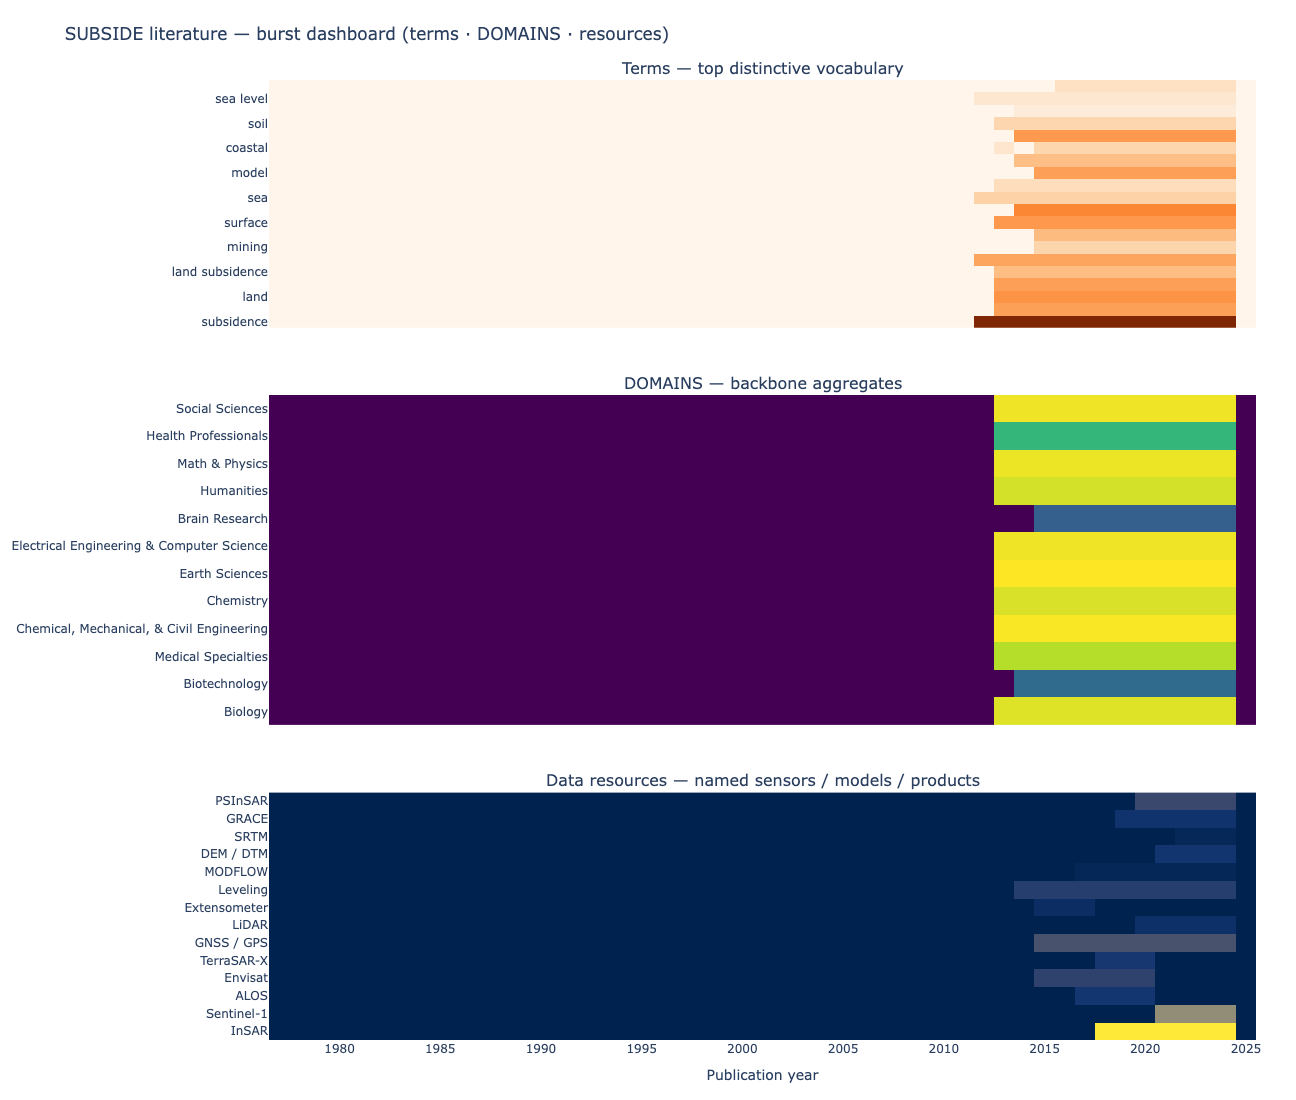

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/burst_dashboard.html


In [19]:
if len(docs_year):
    fig_dash = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        vertical_spacing=0.07,
        row_heights=[0.30, 0.40, 0.30],
        subplot_titles=("Terms — top distinctive vocabulary",
                        "DOMAINS — backbone aggregates",
                        "Data resources — named sensors / models / products"),
    )

    fig_dash.add_trace(go.Heatmap(
        z=matrix, x=years_axis, y=burst_terms,
        colorscale="Oranges", showscale=False,
        hovertemplate="Year %{x}<br>Term: %{y}<br>Intensity: %{z:.2f}<extra></extra>",
    ), row=1, col=1)

    fig_dash.add_trace(go.Heatmap(
        z=matrix_d, x=years_axis, y=domain_names,
        colorscale="Viridis", showscale=False,
        hovertemplate="Year %{x}<br>Domain: %{y}<br>Intensity: %{z:.2f}<extra></extra>",
    ), row=2, col=1)

    fig_dash.add_trace(go.Heatmap(
        z=matrix_r, x=years_axis, y=res_names,
        colorscale="Cividis", showscale=False,
        hovertemplate="Year %{x}<br>Resource: %{y}<br>Intensity: %{z:.2f}<extra></extra>",
    ), row=3, col=1)

    fig_dash.update_layout(
        title="SUBSIDE literature — burst dashboard (terms · DOMAINS · resources)",
        height=1100, plot_bgcolor="white",
        margin=dict(l=200, r=40, t=80, b=60),
    )
    fig_dash.update_xaxes(title_text="Publication year", row=3, col=1)
    fig_dash.write_html(str(OUTPUT_DIR / "burst_dashboard.html"),
                        include_plotlyjs="cdn")
    fig_dash.show()
    print(f"✓ Saved: {OUTPUT_DIR / 'burst_dashboard.html'}")


## 9. Export

Writes the analysis artefacts to `OUTPUT_DIR`:

- `bib_entries_tagged.csv` — every entry with all `group_*` boolean flags
- `keyword_groups.json` — the editable keyword-group definitions used in this run
- `group_mapping.csv` — keyword group → primary backbone domain table
- `lda_topics.csv` — LDA topics surfaced in §3.3
- Plus the four interactive HTML figures already saved in §7–§8.5
- `summary.md` — one-page Markdown digest


In [20]:
!pip install tabulate
from datetime import datetime as _dt
stamp = _dt.now().strftime("%Y%m%d_%H%M%S")

# Tagged entries CSV (flatten list cols)
export_df = df.copy()
export_df["group_matches"] = export_df["group_matches"].str.join("|")
export_df["kw_list"] = export_df["kw_list"].apply(lambda lst: "|".join(lst))
export_df.to_csv(OUTPUT_DIR / f"bib_entries_tagged_{stamp}.csv",
                 index=False, encoding="utf-8-sig")

# Keyword groups JSON
with open(OUTPUT_DIR / f"keyword_groups_{stamp}.json", "w") as fh:
    json.dump(KEYWORD_GROUPS, fh, indent=2)

# Group mapping CSV
gm = group_mapping_df.copy()
gm["backbone_mapping"] = gm["backbone_mapping"].apply(
    lambda hits: " | ".join(f"{d}>{s}({sc})" for d, s, sc in hits))
gm.to_csv(OUTPUT_DIR / f"group_mapping_{stamp}.csv", index=False)

# LDA topics CSV
lda_export = lda_topics_df.copy()
lda_export["top_terms"] = lda_export["top_terms"].apply(lambda lst: ", ".join(lst))
lda_export.to_csv(OUTPUT_DIR / f"lda_topics_{stamp}.csv", index=False)

# Markdown summary
summary_md = f"""# SUBSIDE Science Backbone — Run Summary

- **BibTeX source**: `{BIB_PATH}`
- **Entries loaded**: {len(df):,}
- **Entries with year**: {int(df['year'].notna().sum()):,}
- **Year range**: {int(df['year'].min()) if df['year'].notna().any() else 'n/a'} – {int(df['year'].max()) if df['year'].notna().any() else 'n/a'}
- **Backbone source**: {BACKBONE_SOURCE}
- **Domains**: {len(SCIENCE_BACKBONE)}
- **Keyword groups**: {len(KEYWORD_GROUPS)}
- **LDA topics surfaced**: {N_TOPICS}

## Top 5 keyword groups by document matches
{match_summary.head().to_markdown(index=False)}

## Outputs
- `science_backbone_network.html`
- `burst_terms.html`
- `burst_domains.html`
- `burst_resources.html`
- `burst_dashboard.html`
- `bib_entries_tagged_{stamp}.csv`
- `group_mapping_{stamp}.csv`
- `lda_topics_{stamp}.csv`
- `keyword_groups_{stamp}.json`
"""
with open(OUTPUT_DIR / f"summary_{stamp}.md", "w") as fh:
    fh.write(summary_md)

print(f"✓ All exports written to {OUTPUT_DIR}")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"   · {p.name}")


✓ All exports written to /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults
   · UCSDmap_with_disciplines.net.txt
   · bib_entries_tagged_20260511_012348.csv
   · bib_entries_tagged_20260511_012437.csv
   · bib_entries_tagged_20260511_013008.csv
   · bib_entries_tagged_20260512_063128.csv
   · burst_dashboard.html
   · burst_domains.html
   · burst_resources.html
   · burst_terms.html
   · group_mapping_20260511_012348.csv
   · group_mapping_20260511_012437.csv
   · group_mapping_20260511_013008.csv
   · group_mapping_20260512_063128.csv
   · keyword_groups_20260511_012348.json
   · keyword_groups_20260511_012437.json
   · keyword_groups_20260511_013008.json
   · keyword_groups_20260512_063128.json
   · lda_topics_20260511_012348.csv
   · lda_topics_20260511_012437.csv
   · lda_topics_20260511_013008.csv
   · lda_topics_20260512_063128.csv
   · science_backbone.json
   · science_backbone_network.html
   · summary_20260511_012437.md
   · summary_20260511_013008.md
  

---

## What this notebook does, at a glance

| Section | Role | Source |
|---|---|---|
| 1 | Setup, paths, imports | new |
| 2 | BibTeX ingest → tidy DataFrame, corpus stats | new |
| 3 | Auto-extract keywords (author tags + TF-IDF/LDA) | adapted from `semantic_bridge_cookbook` §3 |
| 4 | User-editable keyword groups + per-doc tagging | adapted from EPH §3.1 |
| 5 | Three-tier science backbone (ETO → sbp → SUBSIDE inline) | adapted from EPH §5.1 |
| 6 | Map keyword groups → backbone domains/subdisciplines | adapted from EPH §5.1 mapper |
| 7 | Interactive backbone network (Plotly) | adapted from EPH §5.2 |
| 8 | Annual Kleinberg bursts for terms, **DOMAINS**, data resources | adapted from EPH §6 |
| 9 | Exports — CSV + HTML + Markdown summary | new |

### Where to customize

- **§1.1** — point `BIB_PATH` at a different bibliography or set `ETO_EXPORT_PATH` to a real CSV to force Tier 1 of the backbone.
- **§3.1** — extend `CUSTOM_STOPWORDS` with corpus-specific noise terms.
- **§4** — the `KEYWORD_GROUPS` dict is the single biggest analytical lever. Add a group, drop a group, refine the term list.
- **§5** — the Tier-3 fallback backbone is also editable: rename a domain, add a subdiscipline, extend the `terms` list.
- **§8.4** — `DATA_RESOURCES` is curated; add the sensors and model codes you actually care about.

### Next steps (training-institute exercises)

1. *Replace* the SUBSIDE `.bib` with a different domain bibliography (e.g., a Texas water-resources `.bib`) and see how the same scaffolding produces a different backbone shape and burst pattern.
2. *Export* an ETO Map-of-Science CSV for the LDA-discovered topics in §3.3 and re-run with `ETO_EXPORT_PATH` set — verify the Tier-1 backbone surfaces the same primary domains as the inlined fallback.
3. *Cross-link* the `bib_entries_tagged.csv` with the CKAN registry's data-resource records and produce a backbone diagram that includes named SUBSIDE datasets as a fourth node tier.
